In [1]:
import simpy
import math
import csv
import random
import matplotlib.pyplot as plt

Enter panel efficiency (0 to 1, default 0.2):  0.2
Enter number of solar panels (default 1):  1
Enter area of each panel in m² (default 1.0):  1.0
Enter battery capacity in kWh (default 10.0):  10
Enter cloud cover percentage (0 to 100, default 30):  30
Enable detailed hourly output? (yes/no, default no):  yes
Enter CSV output filename (default: solar_simulation.csv):  csv


Hour 0: Energy=0.000 kWh, Battery=0.000 kWh, Sunlight=0.000 kW/m², Temp=9.1°C
Hour 1: Energy=0.000 kWh, Battery=0.000 kWh, Sunlight=0.000 kW/m², Temp=8.6°C
Hour 2: Energy=0.000 kWh, Battery=0.000 kWh, Sunlight=0.000 kW/m², Temp=11.3°C
Hour 3: Energy=0.000 kWh, Battery=0.000 kWh, Sunlight=0.000 kW/m², Temp=12.1°C
Hour 4: Energy=0.000 kWh, Battery=0.000 kWh, Sunlight=0.000 kW/m², Temp=15.6°C
Hour 5: Energy=0.000 kWh, Battery=0.000 kWh, Sunlight=0.000 kW/m², Temp=15.6°C
Hour 6: Energy=0.000 kWh, Battery=0.000 kWh, Sunlight=0.000 kW/m², Temp=18.6°C
Hour 7: Energy=0.036 kWh, Battery=0.036 kWh, Sunlight=0.181 kW/m², Temp=21.6°C
Hour 8: Energy=0.070 kWh, Battery=0.106 kWh, Sunlight=0.350 kW/m², Temp=26.0°C
Hour 9: Energy=0.099 kWh, Battery=0.204 kWh, Sunlight=0.495 kW/m², Temp=25.9°C
Hour 10: Energy=0.118 kWh, Battery=0.323 kWh, Sunlight=0.606 kW/m², Temp=30.0°C
Hour 11: Energy=0.133 kWh, Battery=0.455 kWh, Sunlight=0.676 kW/m², Temp=29.0°C
Hour 12: Energy=0.135 kWh, Battery=0.591 kWh, Sunlig

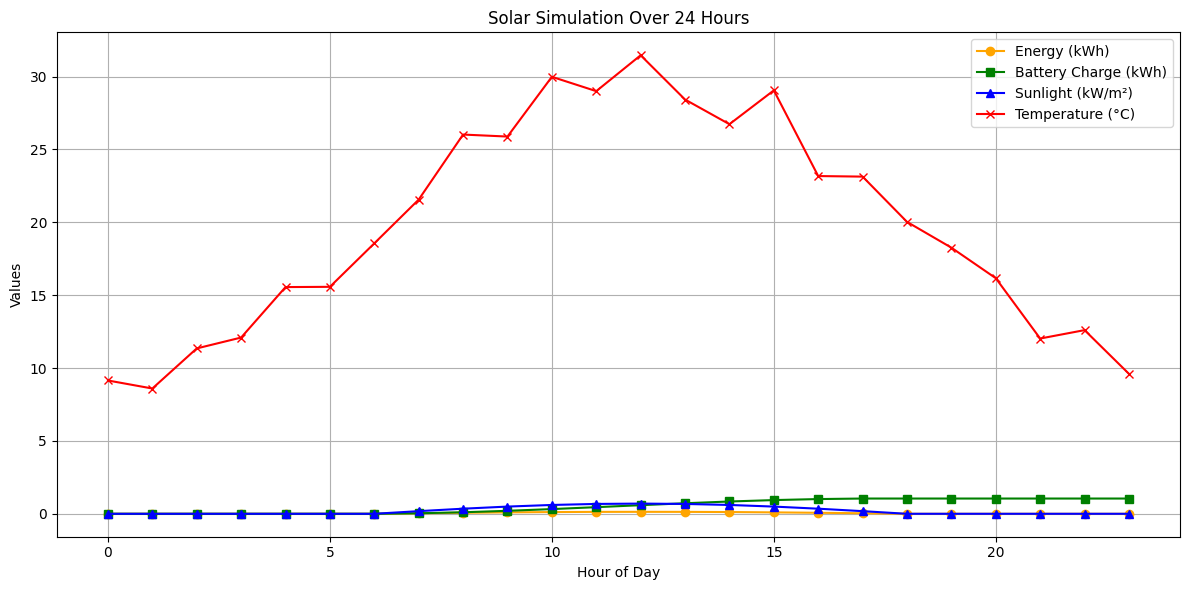

In [2]:
class SolarSystem:
    def __init__(self, env, efficiency=0.2, num_panels=1, area=1.0, battery_capacity=10.0, cloud_cover=30.0, verbose=False):
        self.env = env
        self.efficiency = efficiency
        self.num_panels = num_panels
        self.area = area
        self.battery_capacity = battery_capacity
        self.cloud_cover = cloud_cover
        self.verbose = verbose
        self.energy_output = 0.0
        self.battery_charge = 0.0
        self.data = []

    def calculate_energy(self, hour, temperature):
        sunlight = max(0, math.sin((hour - 6) * math.pi / 12)) * 1000 * (1 - self.cloud_cover / 100)
        temp_effect = 1 - 0.005 * (temperature - 25) if temperature > 25 else 1
        energy = (sunlight * self.efficiency * temp_effect * self.area * self.num_panels) / 1000
        return energy, sunlight, temperature

    def charge_battery(self, energy):
        self.battery_charge = min(self.battery_capacity, self.battery_charge + energy)

    def run(self):
        while True:
            hour = self.env.now % 24
            temperature = 20 + 10 * math.sin((hour - 6) * math.pi / 12) + random.uniform(-2, 2)
            energy, sunlight, temperature = self.calculate_energy(hour, temperature)
            self.energy_output += energy
            self.charge_battery(energy)
            self.data.append({
                'hour': hour,
                'energy': energy,
                'battery_charge': self.battery_charge,
                'sunlight': sunlight / 1000,
                'temperature': temperature
            })
            if self.verbose:
                print(f"Hour {hour}: Energy={energy:.3f} kWh, Battery={self.battery_charge:.3f} kWh, "
                      f"Sunlight={sunlight/1000:.3f} kW/m², Temp={temperature:.1f}°C")
            yield self.env.timeout(1)

    def export_csv(self, filename='solar_simulation.csv'):
        try:
            with open(filename, 'w', newline='') as f:
                writer = csv.DictWriter(f, fieldnames=['hour', 'energy', 'battery_charge', 'sunlight', 'temperature'])
                writer.writeheader()
                writer.writerows(self.data)
            print(f"Data successfully exported to {filename}")
            return True
        except Exception as e:
            print(f"Error exporting data to CSV: {e}")
            return False

    def plot_results(self):
        hours = [d['hour'] for d in self.data]
        energy = [d['energy'] for d in self.data]
        battery = [d['battery_charge'] for d in self.data]
        sunlight = [d['sunlight'] for d in self.data]
        temperature = [d['temperature'] for d in self.data]

        plt.figure(figsize=(12, 6))
        plt.plot(hours, energy, label='Energy (kWh)', marker='o', color='orange')
        plt.plot(hours, battery, label='Battery Charge (kWh)', marker='s', color='green')
        plt.plot(hours, sunlight, label='Sunlight (kW/m²)', marker='^', color='blue')
        plt.plot(hours, temperature, label='Temperature (°C)', marker='x', color='red')
        plt.title('Solar Simulation Over 24 Hours')
        plt.xlabel('Hour of Day')
        plt.ylabel('Values')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

def main():
    try:
        efficiency = float(input("Enter panel efficiency (0 to 1, default 0.2): ") or 0.2)
        num_panels = int(input("Enter number of solar panels (default 1): ") or 1)
        area = float(input("Enter area of each panel in m² (default 1.0): ") or 1.0)
        battery_capacity = float(input("Enter battery capacity in kWh (default 10.0): ") or 10.0)
        cloud_cover = float(input("Enter cloud cover percentage (0 to 100, default 30): ") or 30.0)
        verbose_input = input("Enable detailed hourly output? (yes/no, default no): ").strip().lower()
        verbose = verbose_input == 'yes'
        csv_file = input("Enter CSV output filename (default: solar_simulation.csv): ").strip() or 'solar_simulation.csv'
    except ValueError:
        print("Invalid input provided. Please enter numeric values where required.")
        return

    env = simpy.Environment()
    system = SolarSystem(
        env,
        efficiency=efficiency,
        num_panels=num_panels,
        area=area,
        battery_capacity=battery_capacity,
        cloud_cover=cloud_cover,
        verbose=verbose
    )
    env.process(system.run())
    env.run(until=24)

    print(f"\nSimulation Summary:")
    print(f"Total Energy Generated: {system.energy_output:.3f} kWh")
    print(f"Final Battery Charge: {system.battery_charge:.3f} kWh")
    print(f"Cloud Cover: {system.cloud_cover:.1f}%")
    print(f"Panel Efficiency: {system.efficiency*100:.1f}%")

    system.export_csv(csv_file)
    system.plot_results()

if __name__ == "__main__":
    main()